# KdV Solitons

This notebook lives one folder above `KdVCrumProject`, so it must activate that Julia project before loading the package.

In [1]:
using Pkg
Pkg.activate("KdVCrumProject")

using Revise
using KdVCrumProject
using Plots, LaTeXStrings

  Activating project at `~/Desktop/ResearchProjects/CopyDiluteGas/Dilute Gases/KdVCrumProject`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


One-soliton check against the exact formula.

relative_l2_error(q, q_exact) = 1.5368304631810535e-16


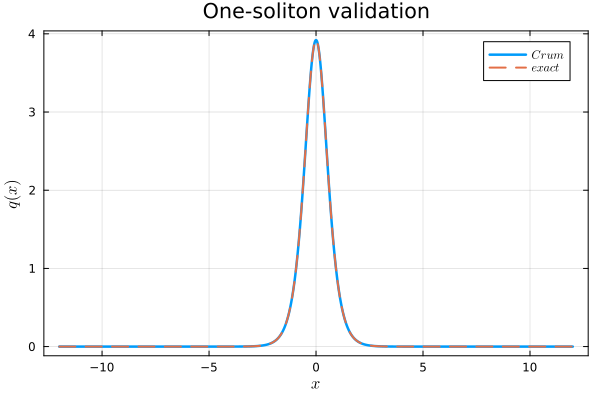

In [2]:
x = collect(range(-12.0, 12.0; length=2001))
kappa = [1.4]
beta = [1.0]

q = crum_transform(x, kappa, beta)
q_exact = exact_one_soliton(x, kappa[1]; beta=beta[1])

@show relative_l2_error(q, q_exact)
plot_comparison(x, q, q_exact; title="One-soliton validation")

A two-soliton reflectionless potential with one shift per eigenvalue.

shifts2 = [-2.5, 1.5]
shifted_norming_constants(kappa2, beta2, shifts2) = [-0.01831563888873418, 164.0219072999017]
minimum(q2) = 3.298876914155126e-15
maximum(q2) = 5.774746608394458
conserved_errors(x2, q2, kappa2) = (6.20503648463e-13, 2.1094237467877974e-15)


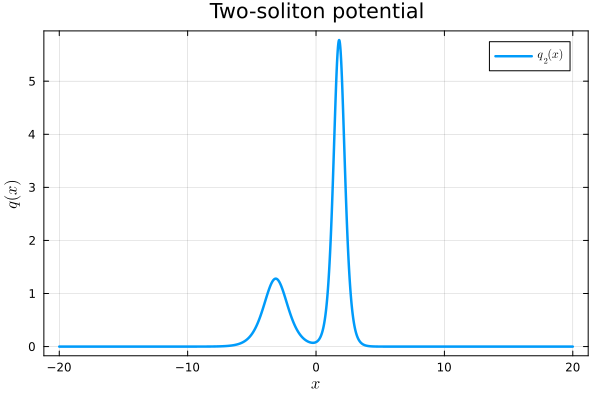

In [3]:
x2 = collect(range(-20.0, 20.0; length=3001))
kappa2 = [0.8, 1.7]
beta2 = alternating_norming_constants(length(kappa2))

shifts2 = [-2.5, 1.5]
q2 = crum_transform(x2, kappa2, beta2; shifts=shifts2)
@show shifts2 shifted_norming_constants(kappa2, beta2, shifts2)
@show minimum(q2) maximum(q2) conserved_errors(x2, q2, kappa2)
plot_potential(x2, q2; title="Two-soliton potential", label=L"q_2(x)")

In [4]:
x = collect(range(-75.0, 75.0; step=0.05))
Ns = [50,100]

function spectrum_for_N(N)
    kappa = uniform_kappa(N; start=0.35, spacing=0.08)
    beta = alternating_norming_constants(N)
    return kappa, beta
end;

In [5]:
stable_results = Dict{Int, Any}()

for N in Ns
    kappa, beta = spectrum_for_N(N)
    elapsed = @elapsed q = crum_transform(x, kappa, beta)
    E1, E2 = conserved_errors(x, q, kappa)
    stable_results[N] = (kappa=kappa, beta=beta, q=q, E1=E1, E2=E2, elapsed=elapsed)
    println("N=", N,
            " finite=", all(isfinite, q),
            " min=", minimum(q),
            " max=", maximum(q),
            " E1=", E1,
            " E2=", E2,
            " elapsed=", round(elapsed; digits=3), " s")
end

N=50 finite=true min=1.0486507174766322e-13 max=18.653661707727924 E1=5.289102489314246e-13 E2=9.0427665355719e-13 elapsed=0.294 s
N=100 finite=true min=3.322286729942099e-11 max=69.12977744917394 E1=1.631856472172899e-8 E2=3.630148182054427e-8 elapsed=1.134 s


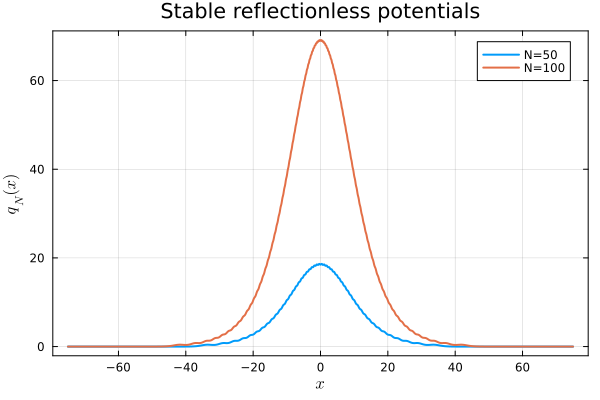

In [6]:
plt = plot(; xlabel=L"x", ylabel=L"q_N(x)", title="Stable reflectionless potentials", framestyle=:box)
for N in Ns
    plot!(plt, x, stable_results[N].q; label="N=$N", linewidth=2)
end
plt

## Time evolution of an N-soliton

For the KdV convention used here, `q_t + 6q q_x + q_xxx = 0`, the eigenvalues `kappa` stay fixed while the norming constants evolve by `beta_n(t) = beta_n(0) exp(8 kappa_n^3 t)`. The `phases` vector below gives one initial spatial/phase shift per soliton.

In [7]:
"""
    N_soliton(x, t, kappa; phases=zeros(length(kappa)), beta=alternating_norming_constants(length(kappa)), digits=nothing)

Return the N-soliton profile q(x,t). The entries of `phases` are the initial
spatial/phase shifts, one for each eigenvalue in `kappa`.
"""
function initial_phases(N::Integer; spacing=4.0, center=0.0, order=:increasing)
    N > 0 || throw(ArgumentError("N must be positive"))
    phases = center .+ spacing .* (collect(1:N) .- (N + 1) / 2)

    if order == :increasing
        return phases
    elseif order == :decreasing
        return reverse(phases)
    else
        throw(ArgumentError("order must be :increasing or :decreasing"))
    end
end

function N_soliton(x, t, kappa; phases=zeros(length(kappa)), beta=alternating_norming_constants(length(kappa)), digits=nothing)
    length(kappa) == length(beta) == length(phases) ||
        throw(ArgumentError("kappa, beta, and phases must have equal length"))

    beta0 = shifted_norming_constants(kappa, beta, phases; digits=digits)
    beta_t = evolve_beta(kappa, beta0, t; digits=digits)
    return crum_transform(x, kappa, beta_t; digits=digits)
end

function n_soliton_evolution_setup(N; kappa_start=0.35, kappa_spacing=min(0.08, 1.0 / N), phase_spacing=0.35, tmax=1.0, nt=81*2+1, margin=8.0, nx=2401*2*2)
    kappa = uniform_kappa(N; start=kappa_start, spacing=kappa_spacing)
    phases = initial_phases(N; spacing=phase_spacing)
    times = range(-tmax, tmax; length=nt)

    fastest_speed = 4 * maximum(kappa)^2
    L = maximum(abs.(phases)) + fastest_speed * tmax + margin
    x = collect(range(-L*3, L*3; length=nx))

    return x, kappa, phases, times
end

# Dense 50-soliton example. Increase phase_spacing if you want the solitons separated more clearly.
N_evol = 10
x_evol, kappa_evol, phases_evol, times_evol = n_soliton_evolution_setup(N_evol)
digits_evol = nothing# Set to 80 or 100 if you increase kappa spacing or tmax substantially.

ylims_evol = (0.0, 1.1 * 2 * maximum(kappa_evol)^2)

# anim = @animate for t in times_evol
#     q_t = N_soliton(x_evol, t, kappa_evol; phases=phases_evol, digits=digits_evol)
#     plot(
#         x_evol,
#         q_t;
#         xlabel=L"x",
#         ylabel=L"q_N(x,t)",
#         label="N=$N_evol",
#         linewidth=2,
#         framestyle=:box,
#         ylims=ylims_evol,
#         title="N-soliton evolution, t=$(round(t; digits=2))",
#     )
# end

# gif(anim, "N_soliton_evolution.gif"; fps=20)

(0.0, 2.518779999999999)

### Single time slice

Rerun only this cell when you want to change `t_slice` without rebuilding the animation.

## Soliton gas evolution

This section uses the existing `soliton_gas_kappa(N, lambda1)` helper from `Utilities.jl` instead of `uniform_kappa` to generate the discrete eigenvalues. Run the first cell to inspect the gas at `t = 0`; run the second cell to build the evolution GIF.

N_gas = 20
first(kappa_gas) = 0.3122498999199199
last(kappa_gas) = 1.0
E1_gas = 5.617534482787045156021462502487601338953434240162599755143996537171681639032372e-05
E2_gas = 3.540273777168732036764510846474019114913721692803632077243593105408648124196313e-08


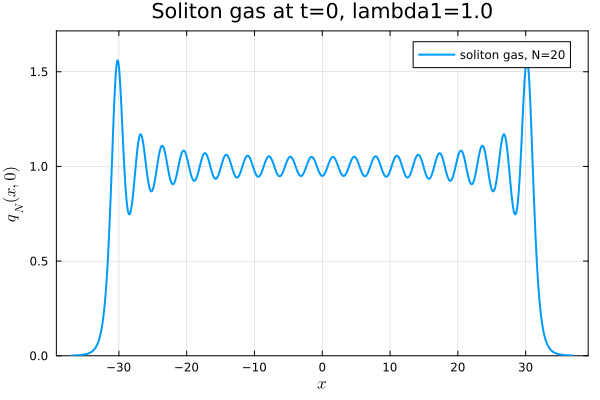

In [8]:
N_gas = 20
lambda1_gas = 1.0
phase_spacing_gas = 0.15
tmax_gas = 1.25
nt_gas = 81
margin_gas = 8.0*(N_gas/5)
nx_gas = 3001

kappa_gas = soliton_gas_kappa(N_gas, lambda1_gas)
beta_gas = alternating_norming_constants(N_gas)

phase_left_gas = -N_gas * pi / (2 * lambda1_gas)
phase_right_gas = N_gas * pi / (2 * lambda1_gas)
phases_gas = 0*collect(range(phase_left_gas, phase_right_gas; length=N_gas))
# phases_gas = initial_phases(N_gas; spacing=phase_spacing_gas)
times_gas = range(-tmax_gas, tmax_gas; length=nt_gas)
digits_gas = 100

fastest_speed_gas = 4 * maximum(kappa_gas)^2
L_gas = maximum(abs.(phases_gas)) + fastest_speed_gas * tmax_gas + margin_gas
x_gas = collect(range(-L_gas, L_gas; length=nx_gas))

q_gas_0 = N_soliton(x_gas, 0.0, kappa_gas; phases=phases_gas, beta=beta_gas, digits=digits_gas)
E1_gas, E2_gas = conserved_errors(x_gas, q_gas_0, kappa_gas)
ylims_gas = (0.0, 1.1 * maximum(q_gas_0))

@show N_gas first(kappa_gas) last(kappa_gas) E1_gas E2_gas
p=plot(
    x_gas,
    q_gas_0;
    xlabel=L"x",
    ylabel=L"q_N(x,0)",
    label="soliton gas, N=$N_gas",
    linewidth=2,
    framestyle=:box,
    ylims=ylims_gas,
    title="Soliton gas at t=0, lambda1=$lambda1_gas",
)

In [9]:
anim_gas = @animate for t in times_gas
    q_t = N_soliton(x_gas, t, kappa_gas; phases=phases_gas, beta=beta_gas, digits=digits_gas)
    plot(
        x_gas,
        q_t;
        xlabel=L"x",
        ylabel=L"q_N(x,t)",
        label="soliton gas, N=$N_gas",
        linewidth=2,
        framestyle=:box,
        ylims=ylims_gas,
        title="Soliton gas evolution, t=$(round(t; digits=2))",
    )
end

gif(anim_gas, "soliton_gas_evolution.gif"; fps=20)

InterruptException: InterruptException:

In [10]:
p=plot(
    x_gas,
    q_gas_0;
    xlabel=L"x",
    ylabel=L"q_N(x,0)",
    label="soliton gas, N=$N_gas",
    linewidth=2,
    framestyle=:box,
    ylims=ylims_gas,
    title="Soliton gas at t=0, lambda1=$lambda1_gas",
)
# savefig(p, "soliton_gas_t0_N$(N_gas).png")
N_gas = 200
lambda1_gas = 1.0
phase_spacing_gas = 0.15
tmax_gas = 1.25
nt_gas = 81
margin_gas = 8.0*(N_gas/5)
nx_gas = 3001

kappa_gas = soliton_gas_kappa(N_gas, lambda1_gas)
beta_gas = alternating_norming_constants(N_gas)

phase_left_gas = -N_gas * pi / (2 * lambda1_gas)
phase_right_gas = N_gas * pi / (2 * lambda1_gas)
phases_gas = 0*collect(range(phase_left_gas, phase_right_gas; length=N_gas))
# phases_gas = initial_phases(N_gas; spacing=phase_spacing_gas)
times_gas = range(-tmax_gas, tmax_gas; length=nt_gas)
digits_gas = 100

fastest_speed_gas = 4 * maximum(kappa_gas)^2
L_gas = maximum(abs.(phases_gas)) + fastest_speed_gas * tmax_gas + margin_gas
x_gas = collect(range(-L_gas, L_gas; length=nx_gas))

q_gas_0 = N_soliton(x_gas, 0.0, kappa_gas; phases=phases_gas, beta=beta_gas, digits=digits_gas)
E1_gas, E2_gas = conserved_errors(x_gas, q_gas_0, kappa_gas)
ylims_gas = (0.0, 1.1 * maximum(q_gas_0))

@show N_gas first(kappa_gas) last(kappa_gas) E1_gas E2_gas
p200=plot!(
    x_gas,
    q_gas_0;
    xlabel=L"x",
    ylabel=L"q_N(x,0)",
    label="soliton gas, N=$N_gas",
    linewidth=1,
    color=:red,
    linestyle=:dash,
    framestyle=:box,
    ylims=ylims_gas,
    title="Soliton gas at t=0, lambda1=$lambda1_gas",
)


InterruptException: InterruptException:

## Soliton gas density heatmap

This cell builds a 20-soliton gas and plots its density in the `(x,t)` plane for `0 <= t <= 25` and `-100 <= x <= 100`.

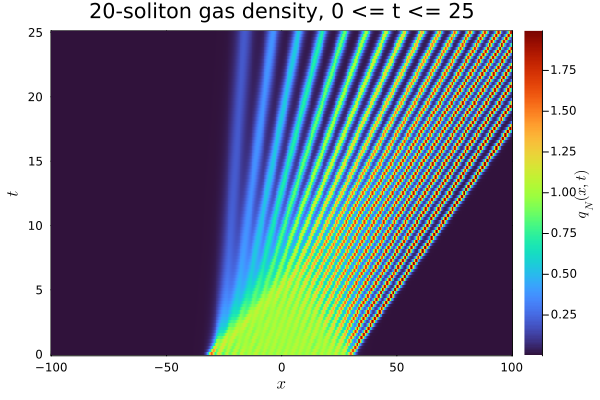

In [15]:
N_heatmap = 20
lambda1_heatmap = 1.0
dilute_c = 0.99
nx_heatmap = 501
nt_heatmap = 101
x_heatmap = collect(range(-100.0, 100.0; length=nx_heatmap))
t_heatmap = collect(range(0.0, 25.0; length=nt_heatmap))

kappa_heatmap = soliton_gas_kappa(N_heatmap, lambda1_heatmap)
beta_heatmap = alternating_norming_constants(N_heatmap)

phase_left_heatmap = -N_heatmap * pi / (2 * lambda1_heatmap)*(1-dilute_c)/dilute_c
phase_right_heatmap = N_heatmap * pi / (2 * lambda1_heatmap)*(1-dilute_c)/dilute_c
# phases_heatmap = 0.0 .* collect(range(phase_left_heatmap, phase_right_heatmap; length=N_heatmap))
phases_heatmap = phase_left_heatmap .+ ( phase_right_heatmap-phase_left_heatmap) .* rand(N_heatmap)
# phases_heatmap = initial_phases(N_heatmap; spacing=0.35)

digits_heatmap = 20 # Set to 80 if you see numerical artifacts.

Q_heatmap = Matrix{Float64}(undef, length(t_heatmap), length(x_heatmap))
for (j, t) in pairs(t_heatmap)
    Q_heatmap[j, :] .= N_soliton(
        x_heatmap,
        t,
        kappa_heatmap;
        phases=phases_heatmap,
        beta=beta_heatmap,
        digits=digits_heatmap,
    )
end

pheat=heatmap(
    x_heatmap,
    t_heatmap,
    Q_heatmap;
    xlabel=L"x",
    ylabel=L"t",
    colorbar_title=L"q_N(x,t)",
    title="20-soliton gas density, 0 <= t <= 25",
    colormap=:turbo,
    framestyle=:box,
    aspect_ratio=:auto,
)


In [13]:
savefig(pheat,"heatmapN50.png")

"/Users/fudong/Desktop/ResearchProjects/CopyDiluteGas/Dilute Gases/heatmapN50.png"